



E-Commerce Transactions Dataset

Task 1: Dataset Understanding

In [ ]:
#import the core python libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [ ]:
#load the retail dataset
# first dataset
df = pd.read_csv('OnlineRetail.csv', encoding='latin1')

#display the first few rows
df.head(10)

#show the number of rows and columns
df.shape

#data types of all columns
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


numerical and categorical features are as follows:
- Unit Price , CustomerID , InvoiceNo , Quantity ( Numerical features)
- Description , stockcode , country ( categorical features )

Possible Primary Keys include - CustomerID

Briefly describe what the dataset contains :
**bold text**

This dataset contains transactional sales data from a UK-based online retail store. It records every purchase made on the platform, capturing details such as the invoice number, product stock code, product description, quantity purchased, unit price, the date of the invoice, the customer ID, and the country the order was placed from. The dataset covers transactions between December 2010 and December 2011 and contains 541,909 rows across 8 columns.


TASK 2 - DATA CLEANING

In [ ]:
#IDENTIFY COLUMNS WITH MISSING VALUES

df.isnull().sum()







,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
#Show the number of missing values per column
df['Country'].isnull().sum()
df['CustomerID'].isnull().sum()
df['Description'].isnull().sum()
df['InvoiceDate'].isnull().sum()
df['InvoiceNo'].isnull().sum()
df['Quantity'].isnull().sum()
df['UnitPrice'].isnull().sum()
df['StockCode'].isnull().sum()

np.int64(0)

In [ ]:
# Handle the missing values appropriately

# Create a cleaned DataFrame by first dropping nulls from 'Description'
df_clean = df.dropna(subset=['Description'])
df['CustomerID_missing'] = df['CustomerID'].isnull()
df['CustomerID'] = df['CustomerID'].fillna('Guest')
df_clean.isnull().sum()




,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,133626
Country,0


In [ ]:
#Handle nulls in CustomerID column

#Converts the entire CustomerID column from int64 (numeric) to string
df['CustomerID'] = df['CustomerID'].astype(str)

# Step 2 — Flag the nulls (they'll now appear as 'nan' after conversion)
df['CustomerID_missing'] = df['CustomerID'] == 'nan'

# Step 3 — Fill with Guest placeholder
df['CustomerID'] = df['CustomerID'].replace('nan', 'Guest')

print(df['CustomerID'].isnull().sum())   # should return 0
print(df['CustomerID'].value_counts().head())



0
CustomerID
Guest      135080
17841.0      7983
14911.0      5903
14096.0      5128
12748.0      4642
Name: count, dtype: int64


Explain why you chose a particular method


In [ ]:
#Explain why you chose a particular method

In [ ]:
#Identify duplicate rows
df.duplicated()
# no duplicate rows were found

,0
0,False
1,False
2,False
3,False
4,False
...,...
541904,False
541905,False
541906,False
541907,False


In [ ]:
#remove duplicates
df = df.drop_duplicates()

In [ ]:
#check if duplicates are gone
df.duplicated().sum()

np.int64(0)

In [ ]:
#check for consistency in date format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
df['formatted_date'] = df['InvoiceDate'].dt.strftime('%Y-%m-%d')

/tmp/ipykernel_414/3999377511.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
/tmp/ipykernel_414/3999377511.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['formatted_date'] = df['InvoiceDate'].dt.strftime('%Y-%m-%d')


In [ ]:
#Original InvoiceDate column
df['InvoiceDate'].head()

#InvoiceDate with formatted dates
df[['InvoiceDate', 'formatted_date']].head()



,InvoiceDate,formatted_date
0,2010-12-01 08:26:00,2010-12-01
1,2010-12-01 08:26:00,2010-12-01
2,2010-12-01 08:26:00,2010-12-01
3,2010-12-01 08:26:00,2010-12-01
4,2010-12-01 08:26:00,2010-12-01


In [ ]:
# TEXT FORMATTING IN TEXT COLUMNS namely Country , Description and StockCode
df['Country'] = df['Country'].str.upper().str.strip()
df['StockCode'] = df['StockCode'].str.upper().str.strip()
df['Description'] = df['Description'].str.upper().str.strip()



/tmp/ipykernel_414/2452634671.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Country'] = df['Country'].str.upper().str.strip()
/tmp/ipykernel_414/2452634671.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['StockCode'] = df['StockCode'].str.upper().str.strip()
/tmp/ipykernel_414/2452634671.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://panda

In [ ]:
#Ensure consistency in column names
#replace a space in a column name with an underscore
df.columns = df.columns.str.upper().str.strip().str.replace(' ','_')
df.columns

Index(['INVOICENO', 'STOCKCODE', 'DESCRIPTION', 'QUANTITY', 'INVOICEDATE',
       'UNITPRICE', 'CUSTOMERID', 'COUNTRY', 'CUSTOMERID_MISSING',
       'FORMATTED_DATE'],
      dtype='object')

In [ ]:
#Check consistency in data types
df.dtypes



,0
INVOICENO,object
STOCKCODE,object
DESCRIPTION,object
QUANTITY,int64
INVOICEDATE,datetime64[ns]
UNITPRICE,float64
CUSTOMERID,object
COUNTRY,object
CUSTOMERID_MISSING,bool
FORMATTED_DATE,object


In [ ]:
#Finding the outliers using IQR for each column
Q1 = df['QUANTITY'].quantile(0.25)
Q3 = df['QUANTITY'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['QUANTITY'] < lower_bound) | (df['QUANTITY'] > upper_bound)]
print(outliers)

Q1 = df['UNITPRICE'].quantile(0.25)
Q3 = df['UNITPRICE'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['UNITPRICE'] < lower_bound) | (df['UNITPRICE'] > upper_bound)]
print(outliers)






       INVOICENO STOCKCODE                         DESCRIPTION  QUANTITY  \
9         536367     84879       ASSORTED COLOUR BIRD ORNAMENT        32   
26        536370     22728           ALARM CLOCK BAKELIKE PINK        24   
27        536370     22727            ALARM CLOCK BAKELIKE RED        24   
30        536370     21883                     STARS GIFT TAPE        24   
31        536370     10002          INFLATABLE POLITICAL GLOBE        48   
...          ...       ...                                 ...       ...   
541876    581585     84945  MULTI COLOUR SILVER T-LIGHT HOLDER        24   
541882    581585     21916     SET 12 RETRO WHITE CHALK STICKS        24   
541883    581585     84692         BOX OF 24 COCKTAIL PARASOLS        25   
541891    581586     23275    SET OF 3 HANGING OWLS OLLIE BEAK        24   
541892    581586     21217       RED RETROSPOT ROUND CAKE TINS        24   

               INVOICEDATE  UNITPRICE CUSTOMERID         COUNTRY  \
9      2010-12-01 0

In [ ]:
# Filtering out the outliers in the quantity column
# Keep all rows where the value is NOT below the lower bound and NOT above the upper bound.
df = df[((df['QUANTITY'] < (Q1 - 1.5 * IQR)) | (df['QUANTITY'] > (Q3 + 1.5 * IQR)))]

In [ ]:
# Filtering out the outliers in the unit price column
# Keep all rows where the value is NOT below the lower bound and NOT above the upper bound.
df = df[((df['UNITPRICE'] < (Q1 - 1.5 * IQR)) | (df['QUANTITY'] > (Q3 + 1.5 * IQR)))]

In [ ]:
#SUMMARY TABLE
import pandas as pd

# Build the summary table
summary = pd.DataFrame({
    'Issue Found': [
        'Missing Values (CUSTOMERID)',
        'Duplicate Rows',
        'Standardization (Column Names)',
        'Standardization (DESCRIPTION)',
        'Standardization (COUNTRY)',
        'Date Format (INVOICEDATE)',
        'Outliers (QUANTITY)',
        'Outliers (UNITPRICE)'
    ],
    'Action Taken': [
        'Filled with Guest placeholder',
        'Removed with drop_duplicates()',
        'Uppercased and stripped',
        'Uppercased and stripped',
        'Uppercased and stripped',
        'Converted to YYYY-MM-DD format',
        'Removed using IQR method',
        'Removed using IQR method'
    ],
    'Status': [
        'Resolved',
        'Resolved',
        'Resolved',
        'Resolved',
        'Resolved',
        'Resolved',
        'Resolved',
        'Resolved'
    ]
})

# Display the table
print(summary.to_string(index=False))

                   Issue Found                   Action Taken   Status
   Missing Values (CUSTOMERID)  Filled with Guest placeholder Resolved
                Duplicate Rows Removed with drop_duplicates() Resolved
Standardization (Column Names)        Uppercased and stripped Resolved
 Standardization (DESCRIPTION)        Uppercased and stripped Resolved
     Standardization (COUNTRY)        Uppercased and stripped Resolved
     Date Format (INVOICEDATE) Converted to YYYY-MM-DD format Resolved
           Outliers (QUANTITY)       Removed using IQR method Resolved
          Outliers (UNITPRICE)       Removed using IQR method Resolved


Task 3: Exploratory Data Analysis (EDA)

In [ ]:
# Mean , Median , Minimum , Maximum , standard deviation of numerical columns
# Numerical values include Quantity and Unit Price

In [ ]:
df['UNITPRICE'].describe()

,UNITPRICE
count,156579.000000
mean,1.606191
std,2.279412
min,0.000000
25%,0.720000
50%,1.250000
75%,1.950000
max,649.500000


In [ ]:
df['QUANTITY'].describe()

,QUANTITY
count,156579.000000
mean,29.672044
std,287.955486
min,9.000000
25%,12.000000
50%,12.000000
75%,24.000000
max,80995.000000


In [ ]:
import pandas as pd

# EXPLORATORY ANALYSES

# Top-selling products
top_products = df.groupby('DESCRIPTION')['QUANTITY'].sum().sort_values(ascending=False).head(10).reset_index()
top_products.columns = ['Product', 'Total Quantity Sold']
print(top_products.to_string(index=False))

# Highest revenue-generating countries
df['REVENUE'] = df['QUANTITY'] * df['UNITPRICE']

top_countries = df.groupby('COUNTRY')['REVENUE'].sum().sort_values(ascending=False).head(10).reset_index()
top_countries.columns = ['Country', 'Total Revenue']
top_countries['Total Revenue'] = top_countries['Total Revenue'].apply(lambda x: f"£{x:,.2f}")
print(top_countries.to_string(index=False))
# Monthly sales trends

# Most purchased products
most_purchased = df.groupby('DESCRIPTION')['INVOICENO'].nunique().sort_values(ascending=False).head(10).reset_index()
most_purchased.columns = ['Product', 'Number of Orders']
print(most_purchased.to_string(index=False))
# Customer purchasing behavior

                           Product  Total Quantity Sold
       PAPER CRAFT , LITTLE BIRDIE                80995
    MEDIUM CERAMIC TOP STORAGE JAR                77673
 WORLD WAR 2 GLIDERS ASSTD DESIGNS                54764
           JUMBO BAG RED RETROSPOT                46097
                    POPCORN HOLDER                35700
   PACK OF 72 RETROSPOT CAKE CASES                35033
WHITE HANGING HEART T-LIGHT HOLDER                31816
     ASSORTED COLOUR BIRD ORNAMENT                31178
                RABBIT NIGHT LIGHT                28674
            MINI PAINT SET VINTAGE                26513
       Country Total Revenue
UNITED KINGDOM £5,606,641.99
   NETHERLANDS   £278,959.53
          EIRE   £202,994.80
       GERMANY   £144,732.01
     AUSTRALIA   £133,035.82
        FRANCE   £127,170.24
   SWITZERLAND    £38,827.96
         JAPAN    £37,027.36
         SPAIN    £36,413.60
        SWEDEN    £35,175.69
                           Product  Number of Orders
           J

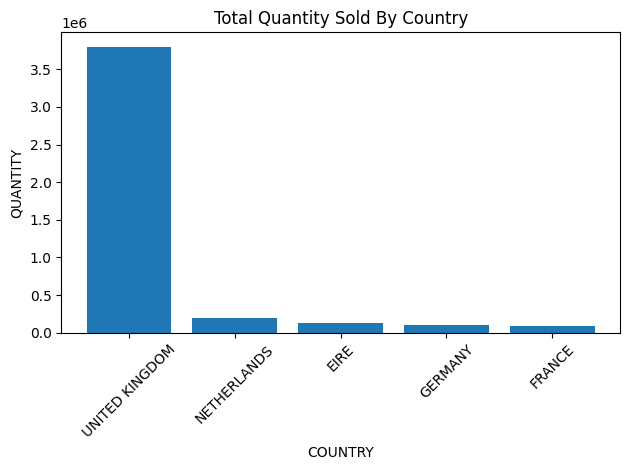

In [ ]:
# 5 visualizations for Retail Data Set
# Bar Graph of total quantity sold by country
x = np.array(df.groupby('COUNTRY')['QUANTITY'].sum().sort_values(ascending=False).head(5).index)

y = np.array(df.groupby('COUNTRY')['QUANTITY'].sum().sort_values(ascending=False).head(5).values)

plt.bar(x, y)
plt.title('Total Quantity Sold By Country')
plt.xlabel('COUNTRY')
plt.ylabel('QUANTITY')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Commentary on bar graph:

This chart displays the top 5 countries ranked by total quantity of items purchased. The United Kingdom stands out with an exceptionally tall bar exceeding 3.75 million units

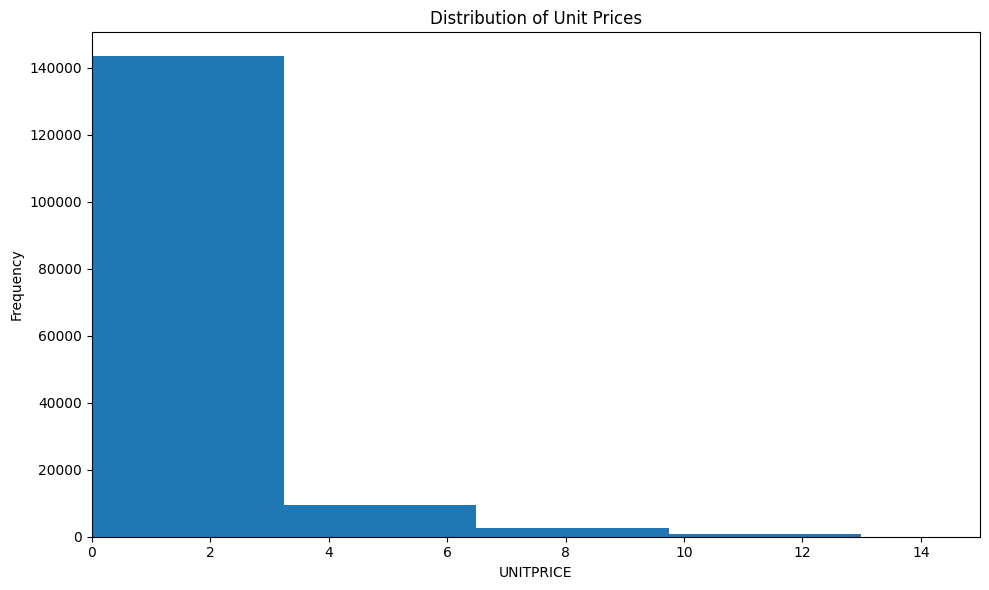

In [ ]:
# Histogram
plt.figure(figsize=(10, 6))
plt.hist(df['UNITPRICE'], bins=200)
plt.title('Distribution of Unit Prices')
plt.xlabel('UNITPRICE')
plt.ylabel('Frequency')
plt.xlim(0, 15)
plt.tight_layout()
plt.show()

Commentary on histogram:The distribution is heavily right-skewed, with the vast majority of products priced between £0 and £3

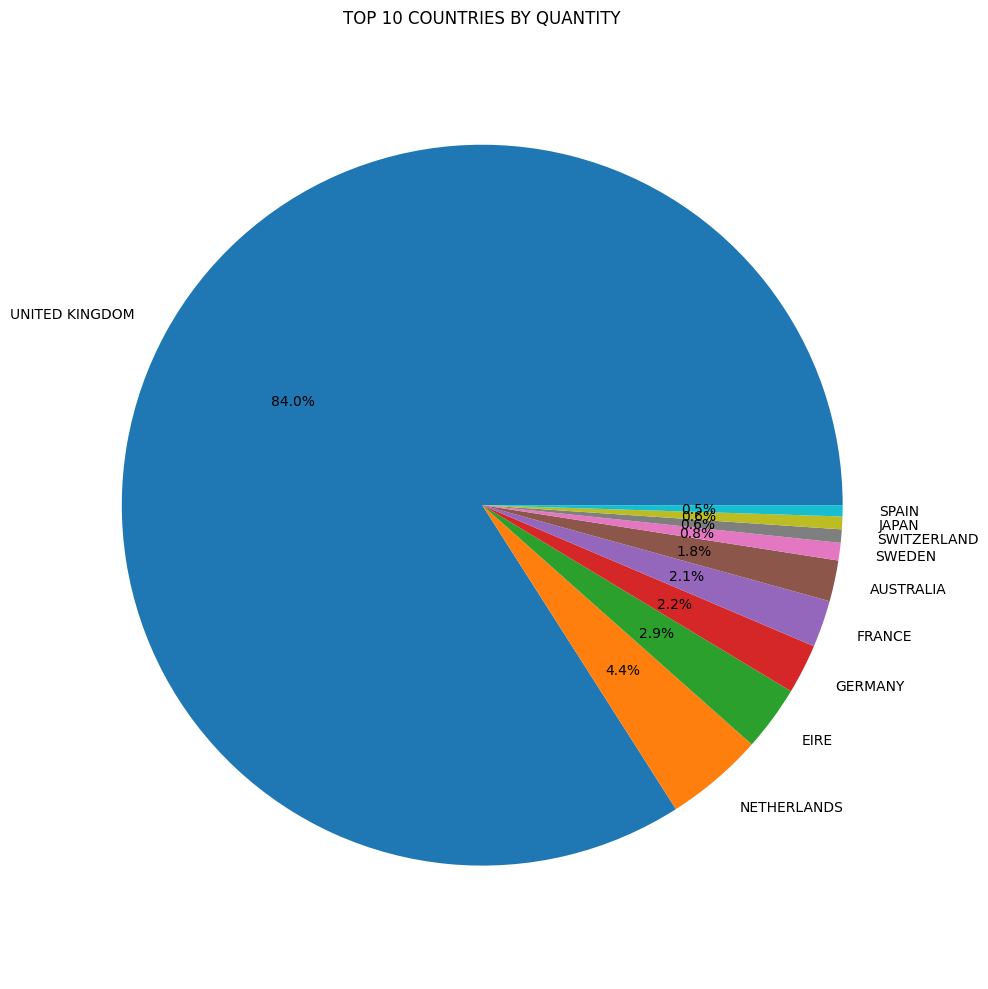

In [ ]:
# PIE CHART
x = np.array(df.groupby('COUNTRY')['QUANTITY'].sum().sort_values(ascending=False).head(10).index)
y = np.array(df.groupby('COUNTRY')['QUANTITY'].sum().sort_values(ascending=False).head(10).values)

plt.figure(figsize=(10,10 ))
plt.pie(y, labels= x, autopct='%1.1f%%')
plt.title('TOP 10 COUNTRIES BY QUANTITY')
plt.axis('equal')
plt.tight_layout()
plt.show()

Commentary on pie chart: The United Kingdom occupies the largest slice by a considerable margin, confirming its dominance not just in quantity sold but also in revenue generated for the business.

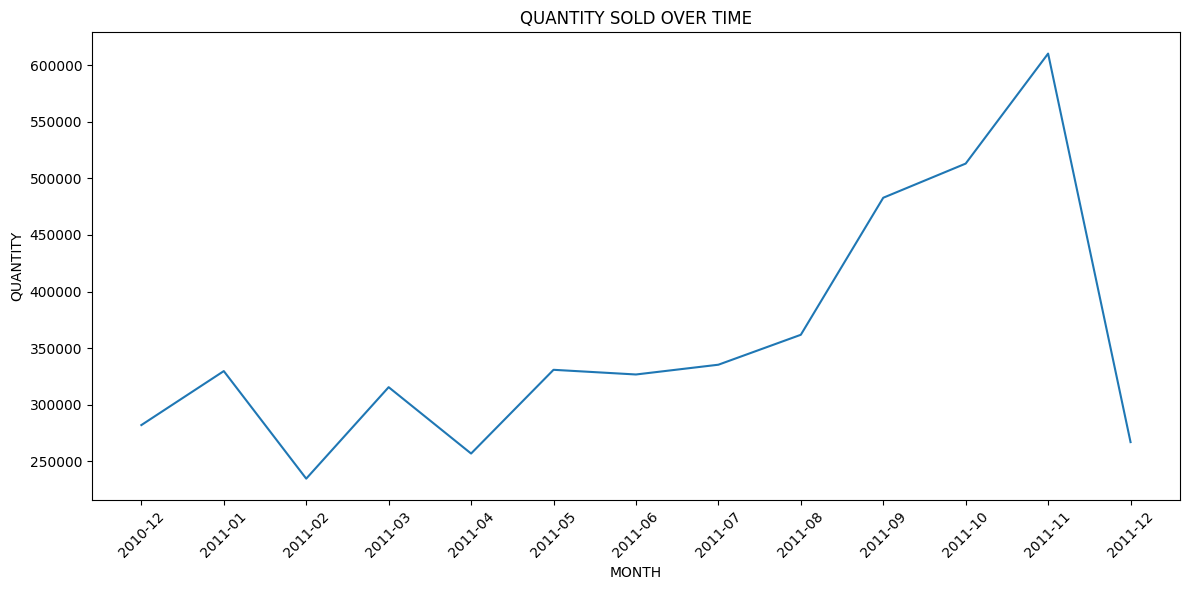

In [ ]:
# Extract month from your existing FORMATTED_DATE column
df['MONTH'] = pd.to_datetime(df['FORMATTED_DATE']).dt.to_period('M').astype(str)

# Aggregate by month
result = df.groupby('MONTH')['QUANTITY'].sum().reset_index()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(result['MONTH'], result['QUANTITY'])
plt.title('QUANTITY SOLD OVER TIME')
plt.xlabel('MONTH')
plt.ylabel('QUANTITY')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Commentary on line graph:
This chart tracks how total quantity sold changed month by month over the period covered by the dataset, with the highest quantity being in 2011-11.

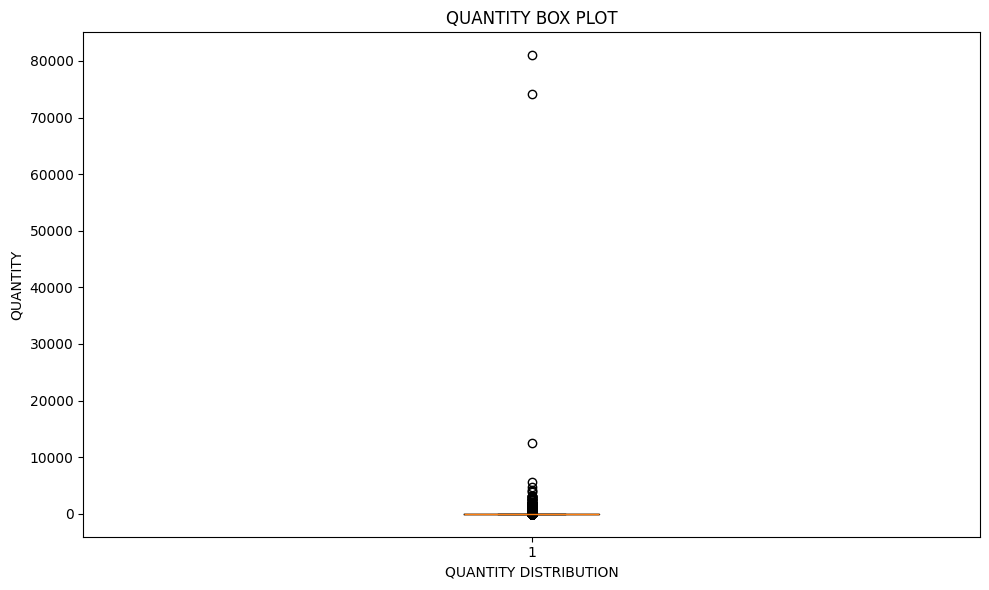

In [ ]:
# BOX PLOT
plt.figure(figsize=(10, 6))
plt.boxplot(df['QUANTITY'])
plt.title('QUANTITY BOX PLOT')
plt.xlabel('QUANTITY DISTRIBUTION')
plt.ylabel('QUANTITY')
plt.tight_layout()
plt.show()

Commentary on box plot:This chart displays the spread of revenue values across all transactions. The box is concentrated at the lower end indicating most transactions generate modest revenue and the dots above represent outliers

Netflix Movies and TV shows dataset

TASK 1

In [ ]:
#import the core python libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset into Python (Pandas) or SQL.
df2 = pd.read_csv('netflix_titles.csv')

#Display the first few rows.
df2.head(10)




,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [ ]:
#Number of rows and columns
df2.shape

(8807, 12)

In [ ]:
#Data types of all columns
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
#Numerical features and Categorical features

**Numerical features** are release year.  

**Categorical features** are description , listed in , rating , duration , date added , country , cast , show_id , type , title , director.      

***Possible unique identifiers (primary keys) include :*** includes show_id



***Briefly describe what the dataset contains:***


TASK 2 DATA CLEANING

In [ ]:
#Identify columns with missing values.
df2.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
#Show the number of missing values per column.
df2['description'].isnull().sum()
df2['listed_in'].isnull().sum()
df2['duration'].isnull().sum()
df2['release_year'].isnull().sum()
df2['date_added'].isnull().sum()
df2['cast'].isnull().sum()
df2['director'].isnull().sum()
df2['title'].isnull().sum()
df2['type'].isnull().sum()
df2['country'].isnull().sum()
df2['rating'].isnull().sum()
df2['show_id'].isnull().sum()


np.int64(0)

In [ ]:
#Handle missing values appropriately.

# Fill missing values in 'director', 'cast', and 'country' with 'Unknown'
df2['director'] = df2['director'].fillna('Unknown')
df2['cast'] = df2['cast'].fillna('Unknown')
df2['country'] = df2['country'].fillna('Unknown')

# Drop rows with missing 'date_added', 'rating', or 'duration' as they are few
df2.dropna(subset=['date_added', 'rating', 'duration'], inplace=True)

# Verify that missing values have been handled
display(df2.isnull().sum())

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


Explain why you chose a particular method

With categorical columns in this context it is best to fill the null values with a value "Unknown"

and then with the numerical columns with null values , 10 , 4 and 3 respectively , dropping these rows is a reasonable approach because they are small amounts of null values.

In [ ]:
#Identify duplicate rows
df2.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
8802,False
8803,False
8804,False
8805,False


In [ ]:
#Remove duplicates where necessary.
df2 = df2.drop_duplicates()

In [ ]:
#Show the number of duplicates removed.
df2.duplicated().sum()


np.int64(0)

In [ ]:
#Ensure consistency in:

# Column names must be consistent before other operations
df2 = pd.read_csv('/content/netflix_titles.csv')
df2.columns = df2.columns.str.strip().str.lower().str.replace(' ', '_')

#Date formats
df2['date_added'] = pd.to_datetime(df2['date_added'].str.strip(), format='%B %d, %Y', errors='coerce')
df2['formatted_date'] = df2['date_added'].dt.strftime('%Y-%m-%d')

#Text formatting (upper/lower case)
df2['type'] = df2['type'].str.strip().str.upper()
df2['country'] = df2['country'].str.strip().str.upper()
df2['rating'] = df2['rating'].str.strip().str.upper()
df2['listed_in'] = df2['listed_in'].str.strip().str.title()

#Data Validation
# Invalid release years
print(df2[df2['release_year'] < 1900])
print(df2[df2['release_year'] > 2023])

# Check rating consistency
print(df2['rating'].value_counts())

# Check type column — should only be Movie or TV Show
print(df2['type'].value_counts())

Empty DataFrame
Columns: [show_id, type, title, director, cast, country, date_added, release_year, rating, duration, listed_in, description, formatted_date]
Index: []
Empty DataFrame
Columns: [show_id, type, title, director, cast, country, date_added, release_year, rating, duration, listed_in, description, formatted_date]
Index: []
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 MIN         1
84 MIN         1
66 MIN         1
Name: count, dtype: int64
type
MOVIE      6131
TV SHOW    2676
Name: count, dtype: int64


### Cleaning Summary

Below is the summary table of the data cleaning steps performed on the Netflix dataset (`df2`).

In [ ]:
import pandas as pd

summary = pd.DataFrame({
    'Issue Found': [
        'Missing Values (director)',
        'Missing Values (cast)',
        'Missing Values (country)',
        'Missing Values (rating)',
        'Duplicate Rows',
        'Invalid Entries (release_year)',
        'Standardization (Column Names)',
        'Standardization (type)',
        'Standardization (country)',
        'Standardization (rating)',
        'Standardization (listed_in)',
        'Date Format (date_added)'
    ],
    'Action Taken': [
        'Filled with Unknown',
        'Filled with Unknown',
        'Filled with Unknown',
        'Filled with Unknown',
        'Removed with drop_duplicates()',
        'Flagged invalid years',
        'Lowercased and stripped',
        'Uppercased and stripped',
        'Uppercased and stripped',
        'Uppercased and stripped',
        'Title cased and stripped',
        'Converted to YYYY-MM-DD format'
    ],
    'Records Affected': [
        f"{df2['director'].isnull().sum()} rows",
        f"{df2['cast'].isnull().sum()} rows",
        f"{df2['country'].isnull().sum()} rows",
        f"{df2['rating'].isnull().sum()} rows",
        f"{df2.duplicated().sum()} rows",
        f"{df2[df2['release_year'] > 2023].shape[0]} rows",
        f"{len(df2.columns)} columns",
        f"{df2['type'].nunique()} unique values",
        f"{df2['country'].nunique()} unique values",
        f"{df2['rating'].nunique()} unique values",
        f"{df2['listed_in'].nunique()} unique values",
        f"{df2['date_added'].notna().sum()} rows"
    ],
    'Status': [
        '✅ Resolved',
        '✅ Resolved',
        '✅ Resolved',
        '✅ Resolved',
        '✅ Resolved',
        '✅ Resolved',
        '✅ Resolved',
        '✅ Resolved',
        '✅ Resolved',
        '✅ Resolved',
        '✅ Resolved',
        '✅ Resolved'
    ]
})

print(summary.to_string(index=False))

summary.style.set_properties(**{
    'text-align': 'left',
    'border': '1px solid black',
    'padding': '8px'
}).set_table_styles([{
    'selector': 'th',
    'props': [('background-color', '#E50914'),
              ('color', 'white'),
              ('font-weight', 'bold')]
}])

                   Issue Found                   Action Taken  Records Affected     Status
     Missing Values (director)            Filled with Unknown         2634 rows ✅ Resolved
         Missing Values (cast)            Filled with Unknown          825 rows ✅ Resolved
      Missing Values (country)            Filled with Unknown          831 rows ✅ Resolved
       Missing Values (rating)            Filled with Unknown            4 rows ✅ Resolved
                Duplicate Rows Removed with drop_duplicates()            0 rows ✅ Resolved
Invalid Entries (release_year)          Flagged invalid years            0 rows ✅ Resolved
Standardization (Column Names)        Lowercased and stripped        13 columns ✅ Resolved
        Standardization (type)        Uppercased and stripped   2 unique values ✅ Resolved
     Standardization (country)        Uppercased and stripped 748 unique values ✅ Resolved
      Standardization (rating)        Uppercased and stripped  17 unique values ✅ Resolved

,Issue Found,Action Taken,Records Affected,Status
0,Missing Values (director),Filled with Unknown,2634 rows,✅ Resolved
1,Missing Values (cast),Filled with Unknown,825 rows,✅ Resolved
2,Missing Values (country),Filled with Unknown,831 rows,✅ Resolved
3,Missing Values (rating),Filled with Unknown,4 rows,✅ Resolved
4,Duplicate Rows,Removed with drop_duplicates(),0 rows,✅ Resolved
5,Invalid Entries (release_year),Flagged invalid years,0 rows,✅ Resolved
6,Standardization (Column Names),Lowercased and stripped,13 columns,✅ Resolved
7,Standardization (type),Uppercased and stripped,2 unique values,✅ Resolved
8,Standardization (country),Uppercased and stripped,748 unique values,✅ Resolved
9,Standardization (rating),Uppercased and stripped,17 unique values,✅ Resolved


Task 3: Exploratory Data Analysis (EDA)

In [ ]:
#Generate Summary Statistics
# Mean , Median , Minimum , Maximum ,Standard Deviation
df2.describe()




,date_added,release_year
count,8797,8807.000000
mean,2019-05-17 05:59:08.436967168,2014.180198
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-06 00:00:00,2013.000000
50%,2019-07-02 00:00:00,2017.000000
75%,2020-08-19 00:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.819312


In [ ]:
# Movies vs TV Shows distribution
# Content added by year
# Top content-producing countries
top_countries = df2[df2['country'] != 'UNKNOWN'].groupby('country')['show_id'].count().sort_values(ascending=False).head(10).reset_index()
top_countries.columns = ['Country', 'Number of Titles']
print(top_countries.to_string(index=False))
# Most common ratings
# Most common genres/categories

       Country  Number of Titles
 UNITED STATES              2818
         INDIA               972
UNITED KINGDOM               419
         JAPAN               245
   SOUTH KOREA               199
        CANADA               181
         SPAIN               145
        FRANCE               124
        MEXICO               110
         EGYPT               106


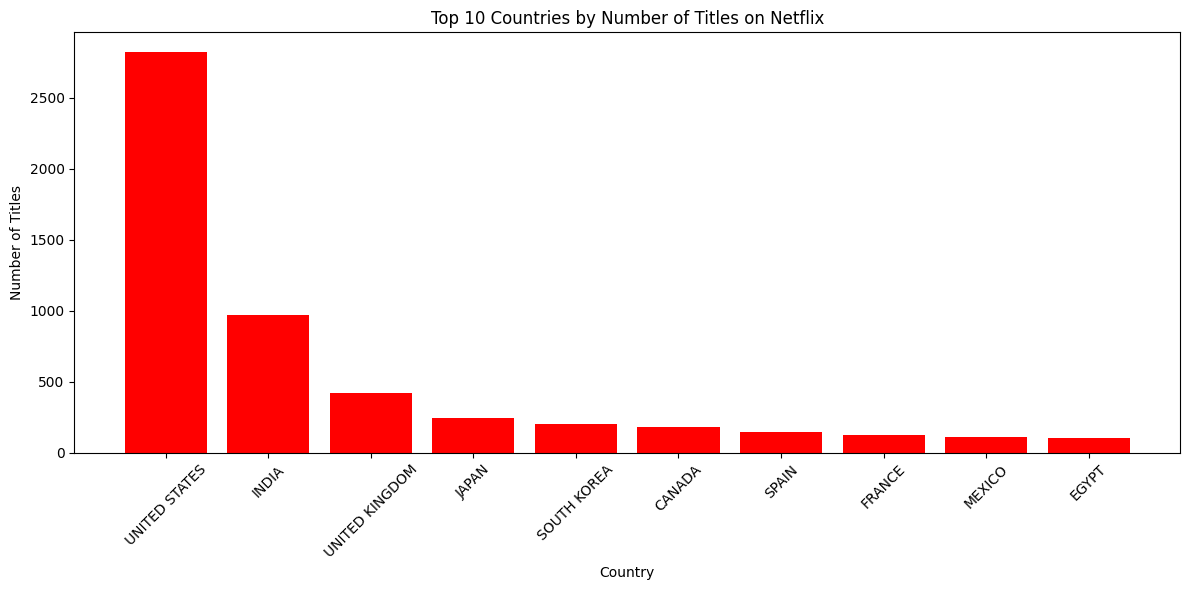

In [ ]:
result = df2.groupby('country')['show_id'].count().sort_values(ascending=False).head(10)
x = np.array(result.index)
y = np.array(result.values)

plt.figure(figsize=(12, 6))
plt.bar(x, y, color='red')
plt.title('Top 10 Countries by Number of Titles on Netflix')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**The United States dominates Netflix content production by a significant margin, followed by India and the United Kingdom. This reflects Netflix's origin as a US-based platform**

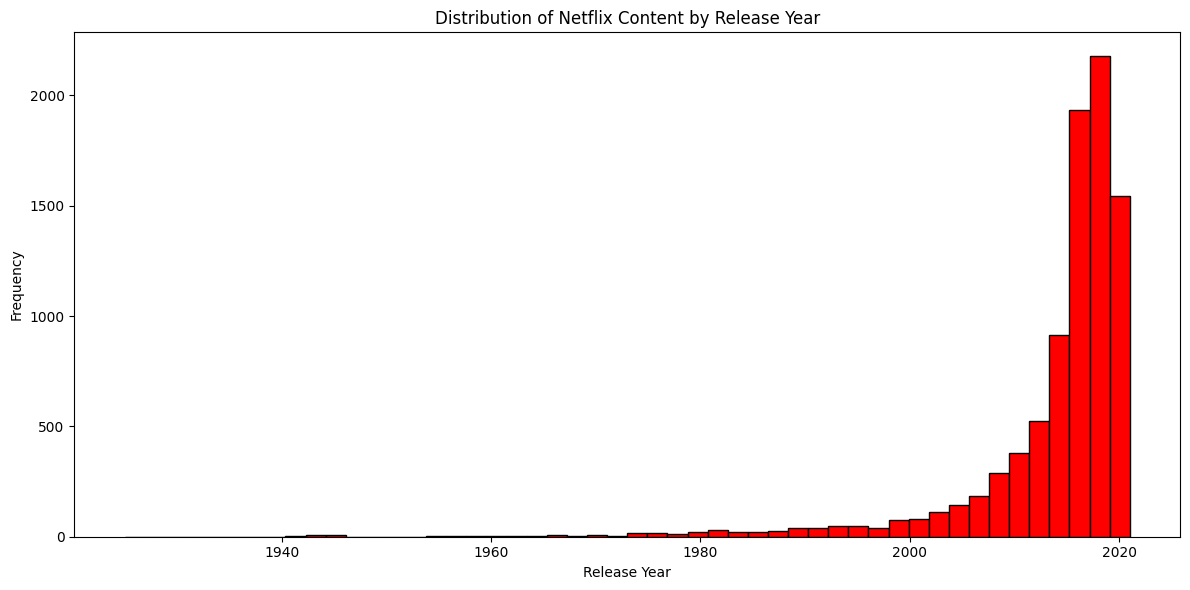

In [ ]:
plt.figure(figsize=(12, 6))
plt.hist(df2['release_year'], bins=50, color='red', edgecolor='black')
plt.title('Distribution of Netflix Content by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

The overwhelming majority of Netflix content was released after 2010, with a sharp spike between 2015 and 2020




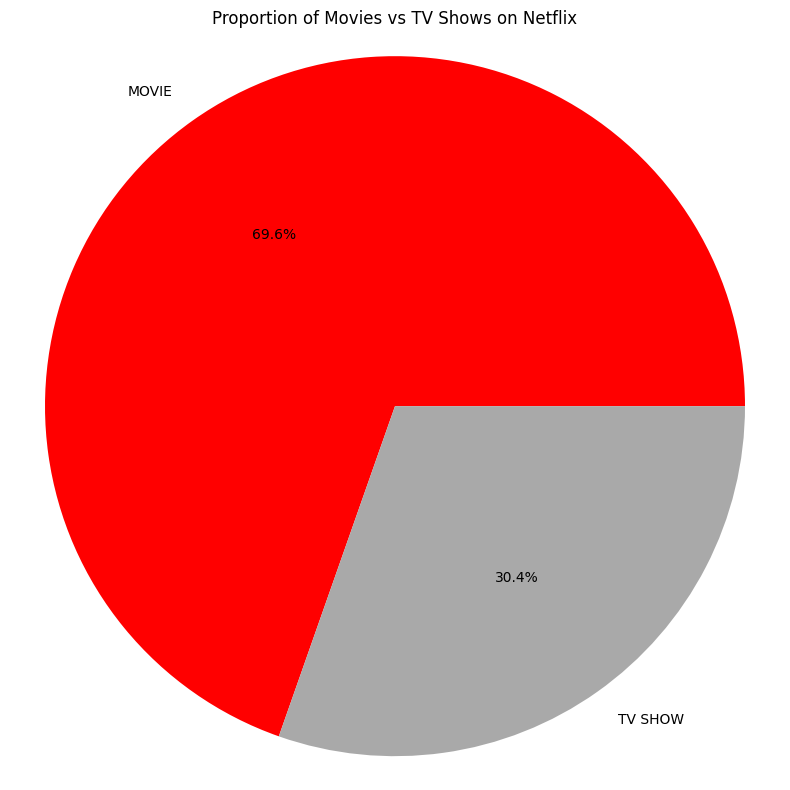

In [ ]:
result = df2['type'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(result.values, labels=result.index, autopct='%1.1f%%',
        colors=['red', 'darkgrey'])
plt.title('Proportion of Movies vs TV Shows on Netflix')
plt.axis('equal')
plt.tight_layout()
plt.show()

**Movies make up the larger share of Netflix's content library compared to TV Shows. This suggests Netflix's catalogue is built primarily around films**

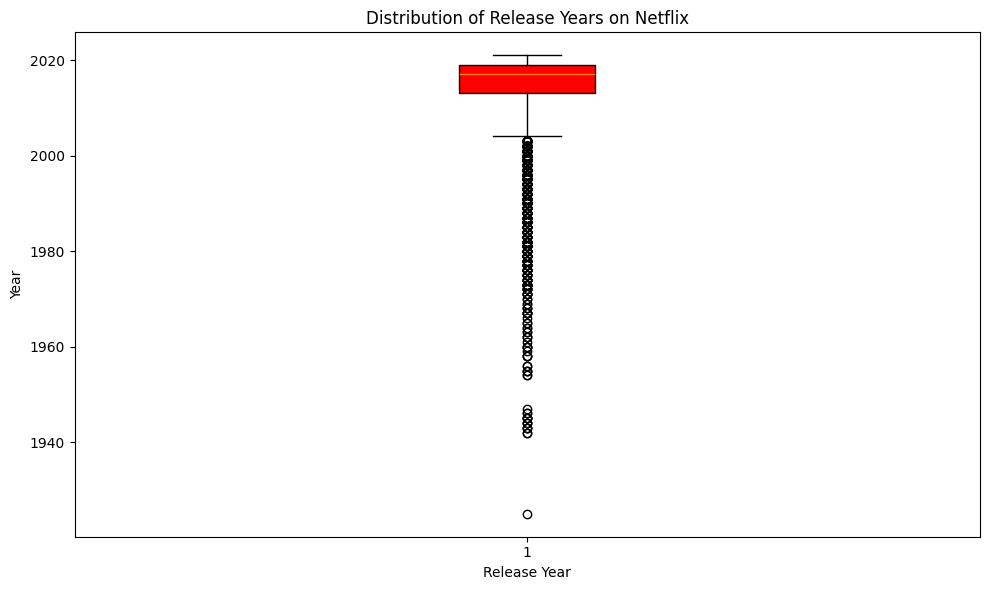

In [ ]:
plt.figure(figsize=(10, 6))
plt.boxplot(df2['release_year'], patch_artist=True,
            boxprops=dict(facecolor='red', color='black'))
plt.title('Distribution of Release Years on Netflix')
plt.xlabel('Release Year')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

**The box plot shows that the median release year sits around 2017, with the middle 50% of content falling between approximately 2013 and 2019. Several outliers exist on the lower end representing older classic titles**

TASK 5

***DATASET 1 INSIGHTS***

Insight 1 — The UK is the dominant market
The bar chart of Total Quantity Sold by Country shows the United Kingdom accounts for over 3.75 million units sold. This suggests the business is overwhelmingly UK-focused and any growth strategy should prioritise retaining the UK market


Insight 2 — This is a low price point, high volume business
The histogram of Unit Price Distribution shows that the vast majority of products are priced between £0 and £3. Very few products exceed £10. This means the business generates revenue through selling large quantities of low-cost items rather than premium pricing

Insight 3 - During data cleaning, 135,080 CustomerID values were null , meaning nearly a quarter of all purchases cannot be linked to a registered customer



***DATASET 2 FINDINGS***

- The bar chart of Top 10 Countries by Number of Titles shows the United States produces significantly more Netflix content than any other country

- The histogram of Release Year Distribution shows a sharp spike in content released between 2015 and 2020, with very little content predating the year 2000. This indicates Netflix actively curates its library toward modern productions

- The pie chart shows Movies make up the larger proportion of Netflix's content library compared to TV Shows